# Лабораторная 1
## Исследование логнормального распределения

### 1. Определение случайных величин. Плотность распределения, функция распределения и характеристическая функция.

Случайная величина $X$ имеет логнормальное распределение, если: $$X \sim \operatorname{LogNormal}(\mu, \sigma)$$
где $\mu$ - математическое ожидание, $\sigma^2$ - дисперсия соответсвующего нормального распределения.

$$f(x) = \frac{1}{x \sigma \sqrt{2\pi}} \, \exp\!\left( -\frac{(\ln x - \mu)^2}{2\sigma^2} \right), \quad x > 0.$$

$$F(x) = \Phi\!\left( \frac{\ln x - \mu}{\sigma} \right), \quad x > 0,
\quad \text{где } \Phi(z) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{z} e^{-t^2/2} \, dt.$$
$$\varphi_X(t) = \int_{0}^{\infty} e^{itx} \frac{1}{x\sigma\sqrt{2\pi}} \exp\!\left( -\frac{(\ln x - \mu)^2}{2\sigma^2} \right) dx, \quad t \in \mathbb{R}.$$

Подключение нужных библиотек.

In [166]:
import matplotlib.pyplot as plt
import numpy as np
import math
from random import random
from scipy import stats

MU: float = 0
SIGMA: float = 1
MU_ARR: list[float] = [0, 1, 2]
SIGMA_ARR: list[float] = [0.5, 1, 1.5]

Класс для работы с логнормальным распределением: заданные плотность распределения, функция распределения и также два варианта алгоритма Бокса-Мюллера, используемые для генерации случайных величин из логнормального распределения.

In [167]:
class Lognorm:
    def __init__(self, mu: float, sigma: float):
        self._mu = mu
        self._sigma = sigma

    def pdf(self, x: float)->float:
        if x <= 0.0:
            return 0
        return np.exp(-(np.log(x) - self._mu) ** 2 / (2 * self._sigma ** 2)) / (x * self._sigma * np.sqrt(2 * np.pi))
    
    def cdf(self, x: float)->float:
        if x <= 0.0:
            return 0
        return stats.norm.cdf((np.log(x) - self._mu) / self._sigma).min()
    
    def generate(self, size: int)->list[float]:
        data: list[float] = []
        x: float = 0.0; y: float = 0.0
        for _ in range(size // 2):
            x, y = random(), random()
            if y == 0.0:
                y = 1
            z1 = np.cos(2 * np.pi * x) * np.sqrt(-2 * np.log(y))
            z2 = np.sin(2 * np.pi * x) * np.sqrt(-2 * np.log(y))
            data.append(np.exp(z1 * self._sigma + self._mu))
            data.append(np.exp(z2 * self._sigma + self._mu))
        return data
    
    def generate2(self, size: int)->list[float]:
        data: list[float] = []
        x: float = 0.0; y: float = 0.0
        for _ in range(size // 2):
            s: float = 10
            while s > 1 or s == 0:
                x, y = random() * 2 - 1, random() * 2 - 1
                s = x ** 2 + y ** 2

            coef = np.sqrt(-2 * np.log(s) / s)
            z1 = x * coef
            z2 = y * coef
            data.append(np.exp(z1 * self._sigma + self._mu))
            data.append(np.exp(z2 * self._sigma + self._mu))
        return data

### 2. Графики плотности и функции распределения.

Зафиксируем $\sigma=1$ и рассмотрим три значения $\mu = 0, 1, 2$. Построим плотности и функции распределения:

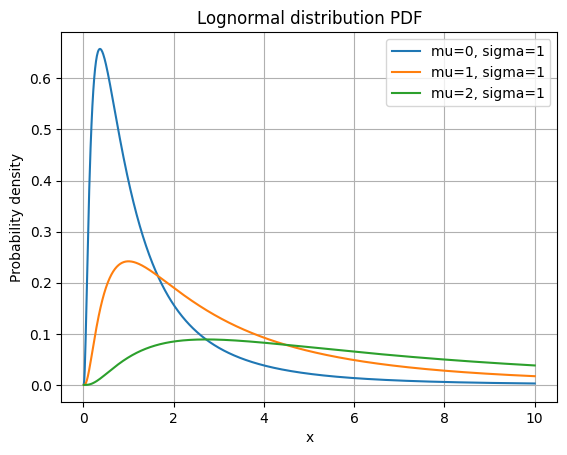

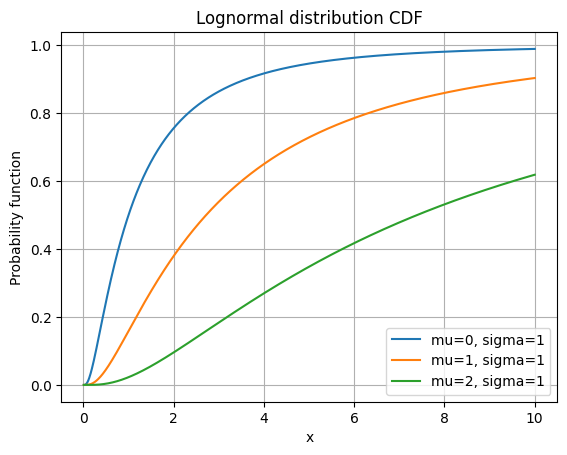

In [168]:
x: np.ndarray = np.linspace(0.01, 10, 1000)

for i in MU_ARR:
    lognorm_distr = Lognorm(i, SIGMA)
    y = [lognorm_distr.pdf(i) for i in x]
    plt.plot(x, y, label=f"mu={i}, sigma={SIGMA}")
plt.xlabel("x")
plt.ylabel("Probability density")
plt.title("Lognormal distribution PDF")
plt.grid(True)
plt.legend()
plt.show()

for i in MU_ARR:
    lognorm_distr = Lognorm(i, SIGMA)
    y = [lognorm_distr.cdf(i) for i in x]
    plt.plot(x, y, label=f"mu={i}, sigma={SIGMA}")
plt.xlabel("x")
plt.ylabel("Probability function")
plt.title("Lognormal distribution CDF")
plt.grid(True)
plt.legend()
plt.show()

Вывод: 
1. Плотность: с увеличением параметра $\mu$ самая мода смещается вправо и становится ниже. Сам график становится более пологим.
2. Функция распределения: точка перегиба с увеличением $\mu$ смещается вправо и функция возрастает намого медленнее.

Зафиксируем $\mu=1$ и рассмотрим три значения $\sigma = 0, 1, 2$. Построим плотности и функции распределения:

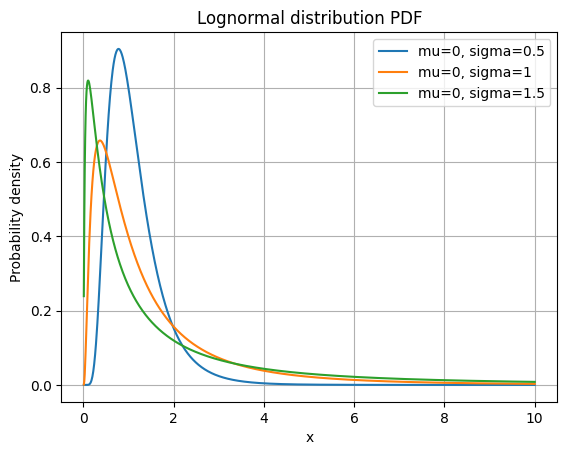

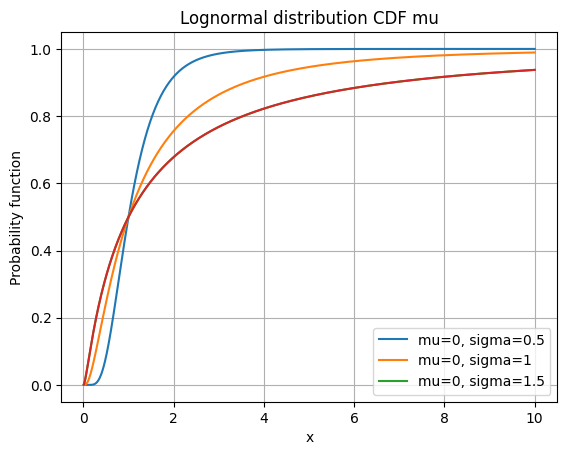

In [169]:
x: np.ndarray = np.linspace(0.01, 10, 1000)

for i in SIGMA_ARR:
    lognorm_distr = Lognorm(MU, i)
    y = [lognorm_distr.pdf(i) for i in x]
    plt.plot(x, y, label=f"mu={MU}, sigma={i}")
plt.xlabel("x")
plt.ylabel("Probability density")
plt.title("Lognormal distribution PDF")
plt.grid(True)
plt.legend()
plt.show()

for i in SIGMA_ARR:
    lognorm_distr = Lognorm(MU, i)
    y = [lognorm_distr.cdf(i) for i in x]
    plt.plot(x, y, label=f"mu={MU}, sigma={i}")
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("Probability function")
plt.title("Lognormal distribution CDF mu")
plt.grid(True)
plt.legend()
plt.show()

Вывод: 
1. Плотность: при небольших параметрах $\sigma$ распределение близко к нормальному, но имеет небольшой скок влево. При $sigma=1$ мода смещается левее и становится ниже, распределение становится более ассимметричным, правый хвост удлиняется. При больших $sigma$ мода смещается ещё левее, большая часть зачений сосредоточена возле нуля. Пик низкий и широкий.
2. Функция распределения: с увеличением $sigma$ подъём графика становится медленнее

## 3. Моделирование случайной выборки. Точность моделирования (критерии). Алгоритм моделирования.

Алгоритм:
1. Генерируются случайные величины, имеющие нормальное распределение при помощи второго варианта алгортма Бокса-Мюллера.
2. Берётся логарифм от этих случайных величин.

Используются два статистических критерия: $\Chi_2$-критерий и критерий Шапиро-Уилка. Посколько критерий Шапиро-Уилка используется только для нормального распределения, в нём используется прологарифмированная выборка

In [170]:
lognorm_distr = Lognorm(MU, SIGMA)

sample = lognorm_distr.generate2(1000)

x = np.linspace(min(sample), max(sample), 1000)
y = [lognorm_distr.pdf(i) for i in x]

ks_stat, ks_p_value = stats.kstest(sample, stats.lognorm.cdf, args=(SIGMA, 0, np.exp(MU)))
print(f"Kolmogorov-Smirnov test: statistic={ks_stat}, p-value={ks_p_value}")

sample_logged = np.log(sample)
shapiro_stat, shapiro_p_value = stats.shapiro(sample_logged)
print(f"Shapiro-Wilk test: statistic={shapiro_stat}, p-value={shapiro_p_value}")

Kolmogorov-Smirnov test: statistic=0.041216117432322674, p-value=0.0650603319559655
Shapiro-Wilk test: statistic=0.9981572531976922, p-value=0.3548553559414569


## 4. Оценка параметров распределения. Точность оценивания (критерии).

Параметрами распределения являются математическое ожидание и стандартное нормальное отклонение, находятся их оценки.

In [171]:
print(f"Estimated mean: {np.mean(sample_logged)}")
print(f"Estimated variance: {np.var(sample_logged)}")

Estimated mean: 0.054459138660634884
Estimated variance: 0.9700283443409973


## 5. Оценка плотности распределения

Для оценки плотности распределения используется ядерная оценка с гауссовским ядром.

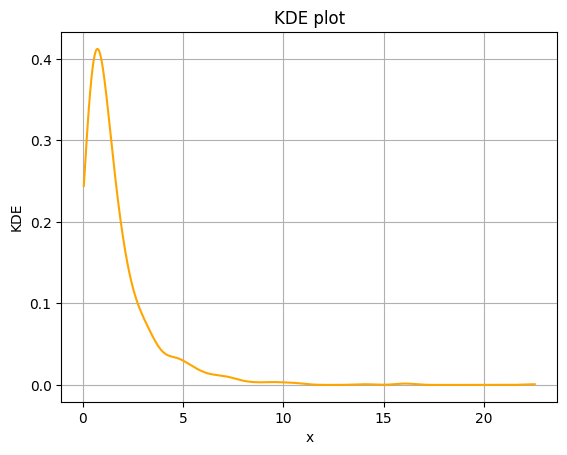

In [172]:
kde = stats.gaussian_kde(sample)
density = kde.evaluate(x)

plt.plot(x, density, color="orange")
plt.xlabel("x")
plt.ylabel("KDE")
plt.title("KDE plot")
plt.grid()
plt.show()

## 6. На одном графике: плотность распределения, гистограмма и оценка плотности распределения

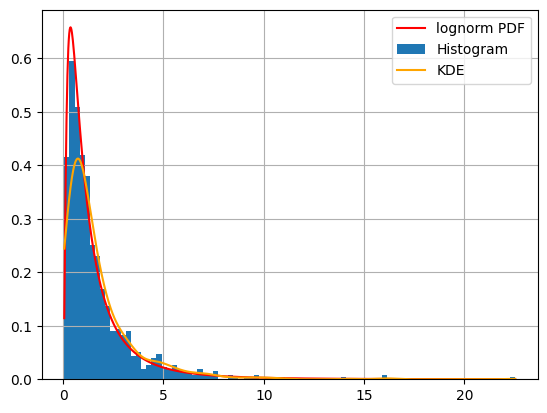

In [173]:
x = np.linspace(min(sample), max(sample), 1000)
pdf = [lognorm_distr.pdf(i) for i in x]

num_bins = math.trunc(max(sample) - min(sample)) * 4

plt.plot(x, pdf, color="red", label="lognorm PDF")
plt.hist(sample, bins=num_bins, density=True, label="Histogram")
plt.plot(x, density, color="orange", label="KDE")

plt.grid()
plt.legend()
plt.show()

## 7. Исследовать квантиль распределения в зависимости от параметров распределения. Вычислить VaR.

Зафиксируем $\sigma=1$. Построим график зависимости квантиля распределения от $\mu$. Возьмём $p=0.95$

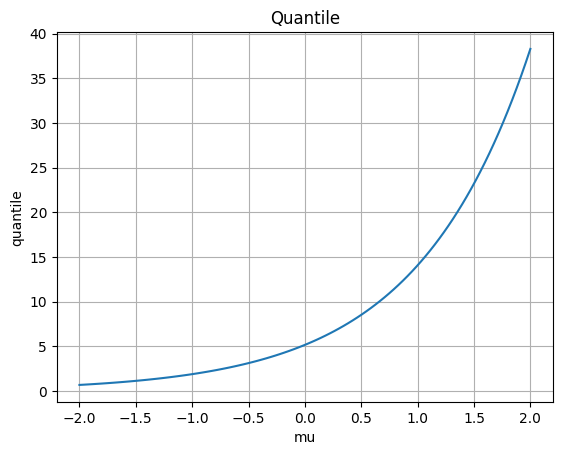

In [174]:
p = 0.95
mu_values = np.linspace(-2, 2, 100)
q = np.exp(mu_values + SIGMA * stats.norm.ppf(p))
plt.plot(mu_values, q)
plt.xlabel("mu")
plt.ylabel("quantile")
plt.grid()
plt.title("Quantile")
plt.show()

Зафиксируем $\mu=0$. Построим график зависимости квантиля распределения от $\sigma$. Возьмём $p=0.95$

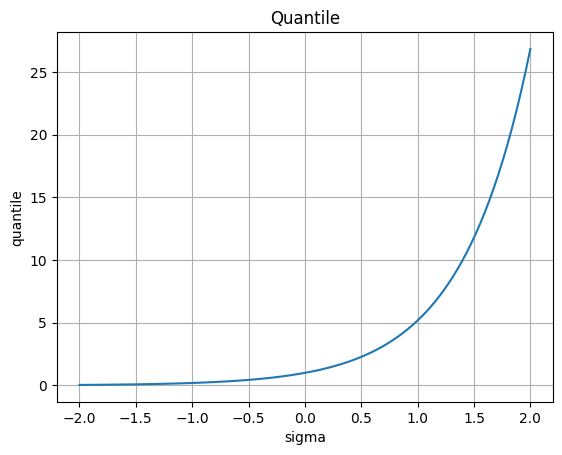

In [175]:
p = 0.95
sigma_values = np.linspace(-2, 2, 100)
q = np.exp(MU + sigma_values * stats.norm.ppf(p))
plt.plot(sigma_values, q)
plt.xlabel("sigma")
plt.ylabel("quantile")
plt.grid()
plt.title("Quantile")
plt.show()

Вычислим VaR:

In [176]:
# Уровни доверия для VaR (левосторонние квантили, т.е. вероятность не превысить)
levels = [0.95, 0.99]

# Теоретические квантили с истинными параметрами
var_true = [np.exp(MU + SIGMA * stats.norm.ppf(p)) for p in levels]
print("VaR (истинные параметры):")
for p, var in zip(levels, var_true):
    print(f"  VaR_{p*100:.0f}% = {var:.4f}")

# Теоретические квантили с оценёнными параметрами
var_mle = [np.exp(np.mean(sample_logged) + np.std(sample_logged) * stats.norm.ppf(p)) for p in levels]
print("\nVaR (оценённые параметры MLE):")
for p, var in zip(levels, var_mle):
    print(f"  VaR_{p*100:.0f}% = {var:.4f}")

VaR (истинные параметры):
  VaR_95% = 5.1803
  VaR_99% = 10.2405

VaR (оценённые параметры MLE):
  VaR_95% = 5.3360
  VaR_99% = 10.4404
